### Titanic Data:

The sinking of the RMS Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew. This sensational tragedy shocked the international community and led to better safety regulations for ships.

One of the reasons that the shipwreck led to such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others, such as women, children, and the upper-class.

Do a complete analysis on what sorts of people were likely to survive.

#### 1) Importing Necessary Libraries:

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin

#### 2) Loading Data:

In [2]:
df = pd.read_csv('titanic_train.csv')
test_df = pd.read_csv('titanic_test.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
print(df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


#### 3) Data Cleaning and Transformations:

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.shape

(891, 12)

In [12]:
print(df['PassengerId'].nunique())
print(df['Ticket'].nunique())
print(df['Name'].nunique())

891
681
891


- PassengerId, Ticket and Name are Unique for Passengers.
- These features won't help in our Predictions for Survival.
- We can Drop these 3 features.

In [13]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis= 1, inplace= True)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [16]:
df.isna().sum() / len(df) * 100

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

- Cabin feature has more than 75% of Missing Values.
- We will drop this feature too.

In [17]:
df.drop('Cabin', axis= 1, inplace= True)

In [18]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


- We have both Numeric and Categorical Features in Data.
- Some features have Missing Values too.
- We will go feature by feature to Clean and Transform.

##### 1) Survived:

- This is Our Target Variable.

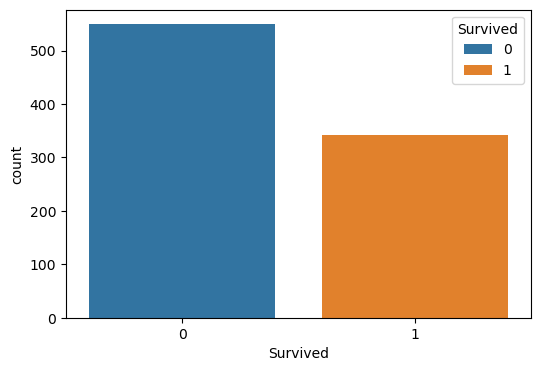

In [19]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'Survived', hue= 'Survived')
plt.show()

In [20]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

- Dataset is Lightly Imbalanced.

##### 2) Pclass:

In [21]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

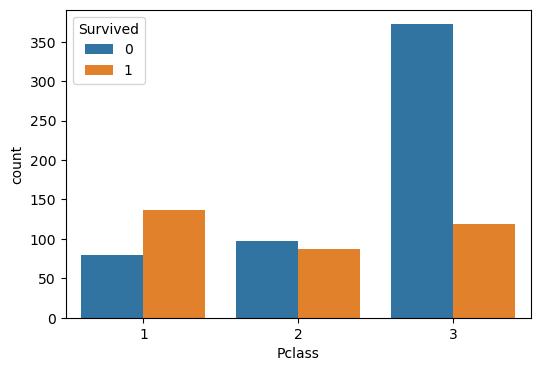

In [22]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'Pclass', hue= 'Survived')
plt.show()

- As we can see, Passenger with Higher Passenger Class has a high Probability of Surviving.
- Hence, Pclass is an Ordinal Categorical Feature.
- Pclass Feature is already Encoded, So we just need to Scale it.

In [59]:
# Preprocessing Pipeline

pclass_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 3) Sex:

In [24]:
df['Sex']

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [25]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

- This is a Categorical and Nominal Feature.
- We will One Hot Encode this feature (No Need to Scale After).

In [58]:
# Preprocessing Pipeline

sex_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 4) Age:

In [27]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

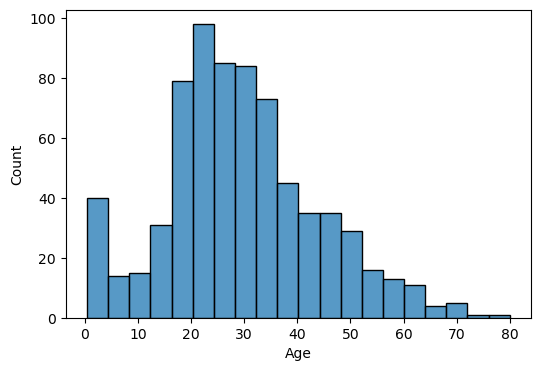

In [28]:
plt.figure(figsize=( 6,4))
sns.histplot(data= df, x= 'Age')
plt.show()

- Age is a Numeric Continuous Feature an it has Missing Values too.
- We will need to Impute Missing Values and then find an appropriate Transformation for Age feature.

In [35]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [36]:
# Finding Correlation of Age with Other Features:

# Temporarily Converting 'Sex' and 'Embarked' features to Numbers to Calculate Correlations.

temp = df.copy()

temp['Sex'] = temp['Sex'].map({'female': 0, 'male': 1})
temp['Embarked'] = temp['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

temp.corr()['Age']

Survived   -0.077221
Pclass     -0.369226
Sex         0.093254
Age         1.000000
SibSp      -0.308247
Parch      -0.189119
Fare        0.096067
Embarked    0.012186
Name: Age, dtype: float64

- "Age" has Relatively High Negative Correlation with "Pcalss".

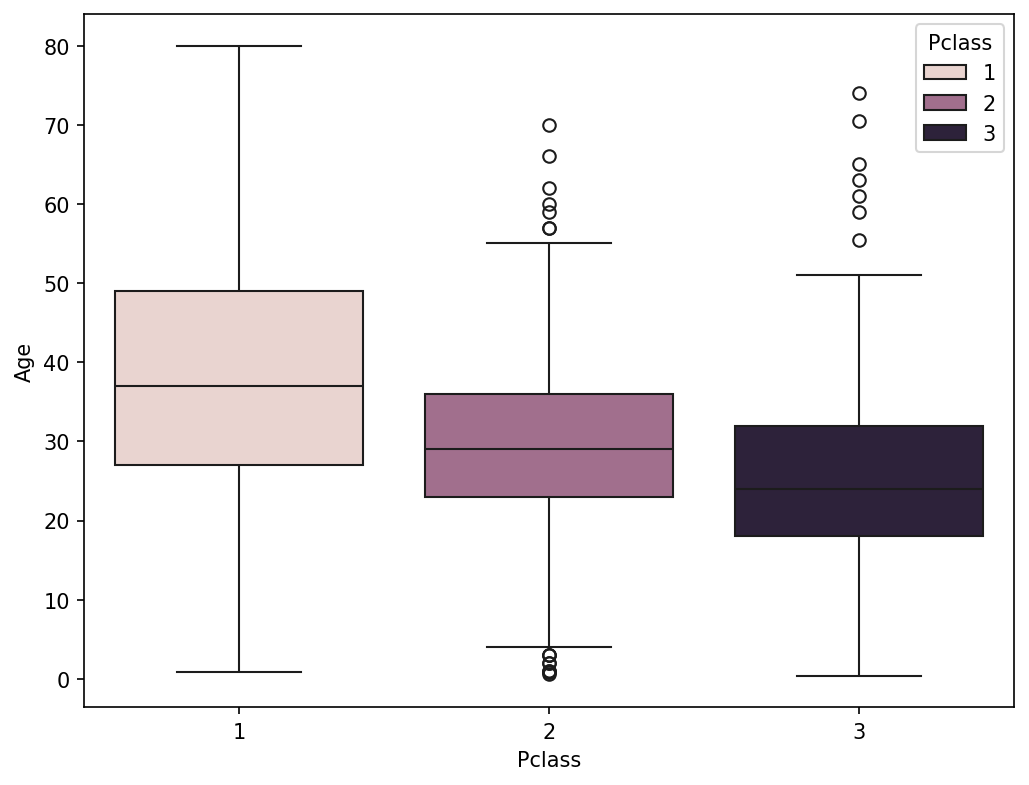

In [38]:
plt.figure(figsize= (8,6), dpi= 150)
sns.boxplot(data= df, x="Pclass", y= "Age", hue= 'Pclass')
plt.show()

- We can see that Younger People are in Lower Class and as Age Increases, People Tend to be in Upper Classes.

- So, We will Fill Missing Values in "Age" according To "Pclass" of that Person.

- i.e., if "Age" is Missing for Person in "Pclass" = 1, we will fill that "Age" value with Median Age of "Pclass"=1.

In [46]:
class GroupImputer(BaseEstimator, TransformerMixin):
    """
    Imputes Missing Values in a Feature by Median of another feature that Particular Missing Value
    Belongs to.

    Parameters
    ----------
    groupby_col : str, default='Pclass'
        Column name to group by for computing medians.
        
    target_col : str, default='Age'
        Column name whose missing values are to be imputed.
        
    agg : str, default='median'
        Aggregation function. Supports 'median' or 'mean'.
        
    fallback_strategy : {'global_median', 'value'}, default='global_median'
        Strategy for unseen or missing group values.
        
    fallback_value : float or int, default=None
        Value used when fallback_strategy='value'.
        
    """

    def __init__(self, groupby_col= 'Pclass', target_col= 'Age', agg= 'median', 
                 fallback_strategy= 'global_median', fallback_value= None):

        self.groupby_col = groupby_col
        self.target_col = target_col
        self.agg= agg
        self.fallback_strategy = fallback_strategy
        self.fallback_value = fallback_value

    def fit(self, X, y= None):

        # Checking if Pandas Dataframe is passed as an Input or not
        if not isinstance(X, pd.DataFrame):
            raise TypeError('Group Imputer requires Pandas Dataframe as Input.')

        # Checking if both Group Column and Target Column Exist in Datframe
        missing_col = [col for col in [self.groupby_col, self.target_col] if col not in X.columns]
        if missing_col:
            raise ValueError(f'Missing Required Column is X: {missing_col}')

        # Computing Group wise Median or Mean:
        if self.agg == 'median':
            group_stats = X.groupby(self.groupby_col)[self.target_col].median()
        
        elif self.agg == 'mean':
            group_stats = X.groupby(self.groupby_col)[self.target_col].mean()

        else:
            raise ValueError("agg must be either 'median' or 'mean'")

        # Storing Group Stats as Dictionary:
        self.group_stats_ = group_stats.to_dict()

        # Computing Fallback Value:
        if self.fallback_strategy == 'global_median':
            self.fallback_ = X[self.target_col].median()

        elif self.fallback_strategy == 'value':
            if self.fallback_value is None:
                raise ValueError("When using fallback_strategy='value', you must provide fallback_value.")
            self.fallback_ = self.fallback_value

        else:
            raise ValueError("fallback_strategy must be 'global_median' or 'value'")

        return self

    def transform(self, X):

        # Checking if Pandas Dataframe is passed as an Input or not
        if not isinstance(X, pd.DataFrame):
            raise TypeError('Group Imputer requires Pandas Dataframe as Input.')

        # Validating
        if self.groupby_col not in X.columns or self.target_col not in X.columns:
            raise ValueError(f"Input must contain '{self.groupby_col}' and '{self.target_col}' columns.")

        X_out = X.copy()

        # Mask missing Age values
        mask = X_out[self.target_col].isna()

        # Map Pclass → median Age
        mapped = X_out.loc[mask, self.groupby_col].map(self.group_stats_)

        # Replace NaN medians (unseen classes) with fallback
        mapped_filled = mapped.fillna(self.fallback_)

        # Assign back
        X_out.loc[mask, self.target_col] = mapped_filled

        return X_out

In [60]:
# Preprocessing Pipeline:

age_pipeline = Pipeline([
    ('imputer', GroupImputer())
])

##### 5) SibSp:

In [62]:
df['SibSp']

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: SibSp, Length: 891, dtype: int64

In [63]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [64]:
df['SibSp'].isna().sum()

np.int64(0)

- SibSp is a categorical nominal feature.
- We will One hot Encode it.

In [92]:
# Preprocessing Pipeline:

sibsp_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 6) Parch:

In [67]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [68]:
df['Parch'].isna().sum()

np.int64(0)

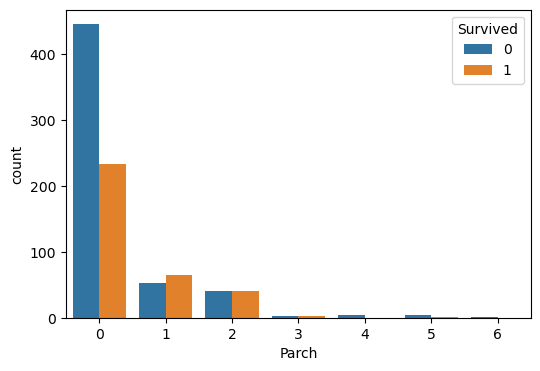

In [70]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'Parch', hue= 'Survived')
plt.show()

- Parch is a Categorical, Nominal Feature.
- We will One Hot Encode it.

In [72]:
# Preprocessing Pipeline:

parch_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [73]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


##### 7) Fare:

In [74]:
df['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [75]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [76]:
df['Fare'].isna().sum()

np.int64(0)

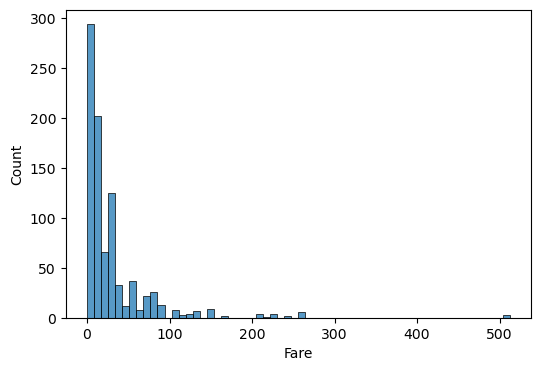

In [77]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Fare')
plt.show()

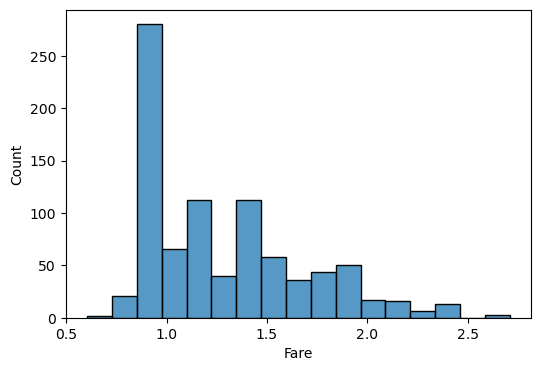

In [84]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Fare'].apply(np.log10))
plt.show()

- Fare is Numeric, Continuous Feature that has a Long Right Tail.
- We will apply 'log10' transformation and then scale it.

In [86]:
fare_pipeline = Pipeline([
    ('transformer', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

##### 8) Embarked:

In [88]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

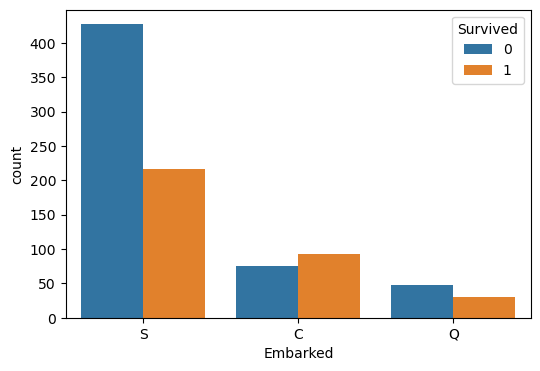

In [89]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'Embarked', hue= 'Survived')
plt.show()

- Embarked is a Categorical, Nomianl Feature.
- We will One Hot Encode it.

In [90]:
# Preprocessing Pipeline:

embarked_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [91]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#### 4) Final Column Transformer:

In [93]:
preprocessor = ColumnTransformer([
    ('Pclass', pclass_pipeline, ['Pclass']),
    ('Sex', sex_pipeline, ['Sex']),
    ('Age', age_pipeline, ['Pclass', 'Age']),
    ('Sibsp', sibsp_pipeline, ['SibSp']),
    ('Parch', parch_pipeline, ['Parch']),
    ('Fare', fare_pipeline, ['Fare']),
    ('Embarked', embarked_pipeline, ['Embarked'])
])